# Проверка регионов по координатам — input_data.csv

Цель: проверить, соответствует ли колонка `id_region` реальному региону объекта по координатам `geo_lat` / `geo_lon`.

In [36]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pd.set_option('display.max_columns', None)

## 1. Загрузка данных

In [37]:
df = pd.read_csv('../data/raw/input_data.csv', sep=';')
print('Shape:', df.shape)
df[['geo_lat', 'geo_lon', 'id_region']].head()

Shape: (11358150, 15)


,geo_lat,geo_lon,id_region
0,56.780112,60.699355,66
1,44.608154,40.138381,1
2,55.540060,37.725112,50
3,44.608154,40.138381,1
4,44.738685,37.713668,23


In [38]:
# Загружаем границы регионов РФ
regions = gpd.read_file('../data/russia_regions.geojson').to_crs('EPSG:4326')

# Маппинг GeoJSON name_latin -> официальный код региона РФ
name_to_code = {
    'Republic of Adygea': 1, 'Republic of Bashkortostan': 2, 'Republic of Buryatia': 3,
    'Altai Republic': 4, 'Republic of Dagestan': 5, 'Republic of Ingushetia': 6,
    'Kabardino-Balkar Republic': 7, 'Republic of Kalmykia': 8, 'Karachay-Cherkess Republic': 9,
    'Republic of Karelia': 10, 'Komi Republic': 11, 'Mari El Republic': 12,
    'Republic of Mordovia': 13, 'Sakha (Yakutia) Republic': 14, 'Republic of North Ossetia-Alania': 15,
    'Republic of Tatarstan': 16, 'Tuva Republic': 17, 'Udmurt Republic': 18,
    'Republic of Khakassia': 19, 'Chechen Republic': 20, 'Chuvash Republic': 21,
    'Altai Krai': 22, 'Krasnodar Krai': 23, 'Krasnoyarsk Krai': 24,
    'Primorsky Krai': 25, 'Stavropol Krai': 26, 'Khabarovsk Krai': 27,
    'Amur Oblast': 28, 'Arkhangelsk Oblast': 29, 'Astrakhan Oblast': 30,
    'Belgorod Oblast': 31, 'Bryansk Oblast': 32, 'Vladimir Oblast': 33,
    'Volgograd Oblast': 34, 'Vologda Oblast': 35, 'Voronezh Oblast': 36,
    'Ivanovo Oblast': 37, 'Irkutsk Oblast': 38, 'Kaliningrad Oblast': 39,
    'Kaluga Oblast': 40, 'Kamchatka Krai': 41, 'Kemerovo Oblast': 42,
    'Kirov Oblast': 43, 'Kostroma Oblast': 44, 'Kurgan Oblast': 45,
    'Kursk Oblast': 46, 'Leningrad Oblast': 47, 'Lipetsk Oblast': 48,
    'Magadan Oblast': 49, 'Moscow Oblast': 50, 'Murmansk Oblast': 51,
    'Nizhny Novgorod Oblast': 52, 'Novgorod Oblast': 53, 'Novosibirsk Oblast': 54,
    'Omsk Oblast': 55, 'Orenburg Oblast': 56, 'Oryol Oblast': 57,
    'Penza Oblast': 58, 'Perm Krai': 59, 'Pskov Oblast': 60,
    'Rostov Oblast': 61, 'Ryazan Oblast': 62, 'Samara Oblast': 63,
    'Saratov Oblast': 64, 'Sakhalin Oblast': 65, 'Sverdlovsk Oblast': 66,
    'Smolensk Oblast': 67, 'Tambov Oblast': 68, 'Tver Oblast': 69,
    'Tomsk Oblast': 70, 'Tula Oblast': 71, 'Tyumen Oblast': 72,
    'Ulyanovsk Oblast': 73, 'Chelyabinsk Oblast': 74, 'Zabaykalsky Krai': 75,
    'Yaroslavl Oblast': 76, 'Moscow': 77, 'Saint Petersburg': 78,
    'Jewish Autonomous Oblast': 79, 'Nenets Autonomous Okrug': 83,
    'Khanty\u2013Mansi Autonomous Okrug \u2013 Yugra': 86,
    'Chukotka Autonomous Okrug': 87, 'Yamalo-Nenets Autonomous Okrug': 89,
}

regions['official_code'] = regions['name_latin'].map(name_to_code)
print('Регионов в GeoJSON:', len(regions))
print('Регионов без кода:', regions['official_code'].isna().sum())

Регионов в GeoJSON: 83
Регионов без кода: 0


## 2. Выборка и Spatial Join

In [39]:
# Выборка 5000 точек с валидными координатами (без кода 200)
sample = df[
    (df['geo_lat'].between(41, 82)) &
    (df['geo_lon'].between(19, 192)) &
    (df['id_region'] != 200)
].sample(5000, random_state=42).copy()

print('Размер выборки:', len(sample))

geometry = [Point(lon, lat) for lon, lat in zip(sample['geo_lon'], sample['geo_lat'])]
gdf = gpd.GeoDataFrame(sample, geometry=geometry, crs='EPSG:4326')

joined = gpd.sjoin(gdf, regions[['official_code', 'name_latin', 'geometry']], how='left', predicate='within')
print('После spatial join:', joined.shape)

Размер выборки: 5000
После spatial join: (5000, 19)


## 3. Проверка совпадений id_region с официальными кодами

In [40]:
matched = joined.dropna(subset=['official_code']).copy()
not_matched = joined[joined['official_code'].isna()]

print(f'Попали в регион: {len(matched)} ({len(matched)/len(joined)*100:.1f}%)')
print(f'Не попали ни в один регион: {len(not_matched)} ({len(not_matched)/len(joined)*100:.1f}%)')

Попали в регион: 4964 (99.3%)
Не попали ни в один регион: 36 (0.7%)


In [41]:
matched['official_code'] = matched['official_code'].astype(int)
matched['match'] = matched['id_region'] == matched['official_code']

n_match = matched['match'].sum()
n_mismatch = (~matched['match']).sum()
print(f'Совпадений:    {n_match} ({matched["match"].mean()*100:.1f}%)')
print(f'Несовпадений:  {n_mismatch} ({(~matched["match"]).mean()*100:.1f}%)')

Совпадений:    4904 (98.8%)
Несовпадений:  60 (1.2%)


## 4. Анализ несовпадений (1.2%)

In [42]:
mismatches = matched[~matched['match']].copy()

# Добавляем название региона из id_region
reg_ref = pd.read_csv('../data/russia_region_codes.csv', dtype={'kladr_id': str})
reg_ref['region_code'] = reg_ref['kladr_id'].str[:2].astype(int)
code_to_name = reg_ref.set_index('region_code')['geoname_name'].to_dict()

mismatches['id_region_name'] = mismatches['id_region'].map(code_to_name)

print(f'Всего несовпадений: {len(mismatches)}')
print()

table = mismatches[['id_region', 'id_region_name', 'official_code', 'name_latin', 'geo_lat', 'geo_lon']].copy()
table.columns = ['Код (датасет)', 'Регион (датасет)', 'Код (карта)', 'Регион (карта)', 'Широта', 'Долгота']
table = table.reset_index(drop=True)
display(table)

Всего несовпадений: 60



,Код (датасет),Регион (датасет),Код (карта),Регион (карта),Широта,Долгота
0,23,Krasnodarskiy,71,Tula Oblast,53.965259,38.337761
1,72,Tyumen Oblast,86,Khanty–Mansi Autonomous Okrug – Yugra,60.040711,69.921897
2,50,Moscow Oblast,77,Moscow,55.697856,37.860665
3,64,Saratovskaya Oblast,66,Sverdlovsk Oblast,56.831344,60.619411
4,74,Chelyabinsk,24,Krasnoyarsk Krai,56.017986,92.842358
5,68,Tambov,23,Krasnodar Krai,45.091781,38.996549
6,50,Moscow Oblast,77,Moscow,55.841640,37.345652
7,77,Moscow,69,Tver Oblast,56.916466,32.164803
8,77,Moscow,50,Moscow Oblast,55.728488,37.341478
9,50,Moscow Oblast,77,Moscow,55.754047,37.620405


In [43]:
# Топ пар несовпадений
print('Топ пар: id_region -> регион по координатам')
top_pairs = mismatches.groupby(['id_region_name', 'name_latin']).size().reset_index(name='count')
top_pairs = top_pairs.sort_values('count', ascending=False)
print(top_pairs.to_string(index=False))

Топ пар: id_region -> регион по координатам
       id_region_name                            name_latin  count
        Moscow Oblast                                Moscow     13
        Tyumen Oblast Khanty–Mansi Autonomous Okrug – Yugra      5
               Moscow                         Moscow Oblast      3
          Chelyabinsk                                Moscow      2
         Tomsk Oblast                           Omsk Oblast      2
               Moscow                           Tver Oblast      2
        Krasnodarskiy                           Tula Oblast      2
          Chelyabinsk                      Krasnoyarsk Krai      1
       St.-Petersburg                    Chelyabinsk Oblast      1
        Samara Oblast                Nizhny Novgorod Oblast      1
  Saratovskaya Oblast                     Sverdlovsk Oblast      1
       St.-Petersburg                                Moscow      1
       St.-Petersburg                      Leningrad Oblast      1
               Ros

## 5. Карта: совпадения и несовпадения

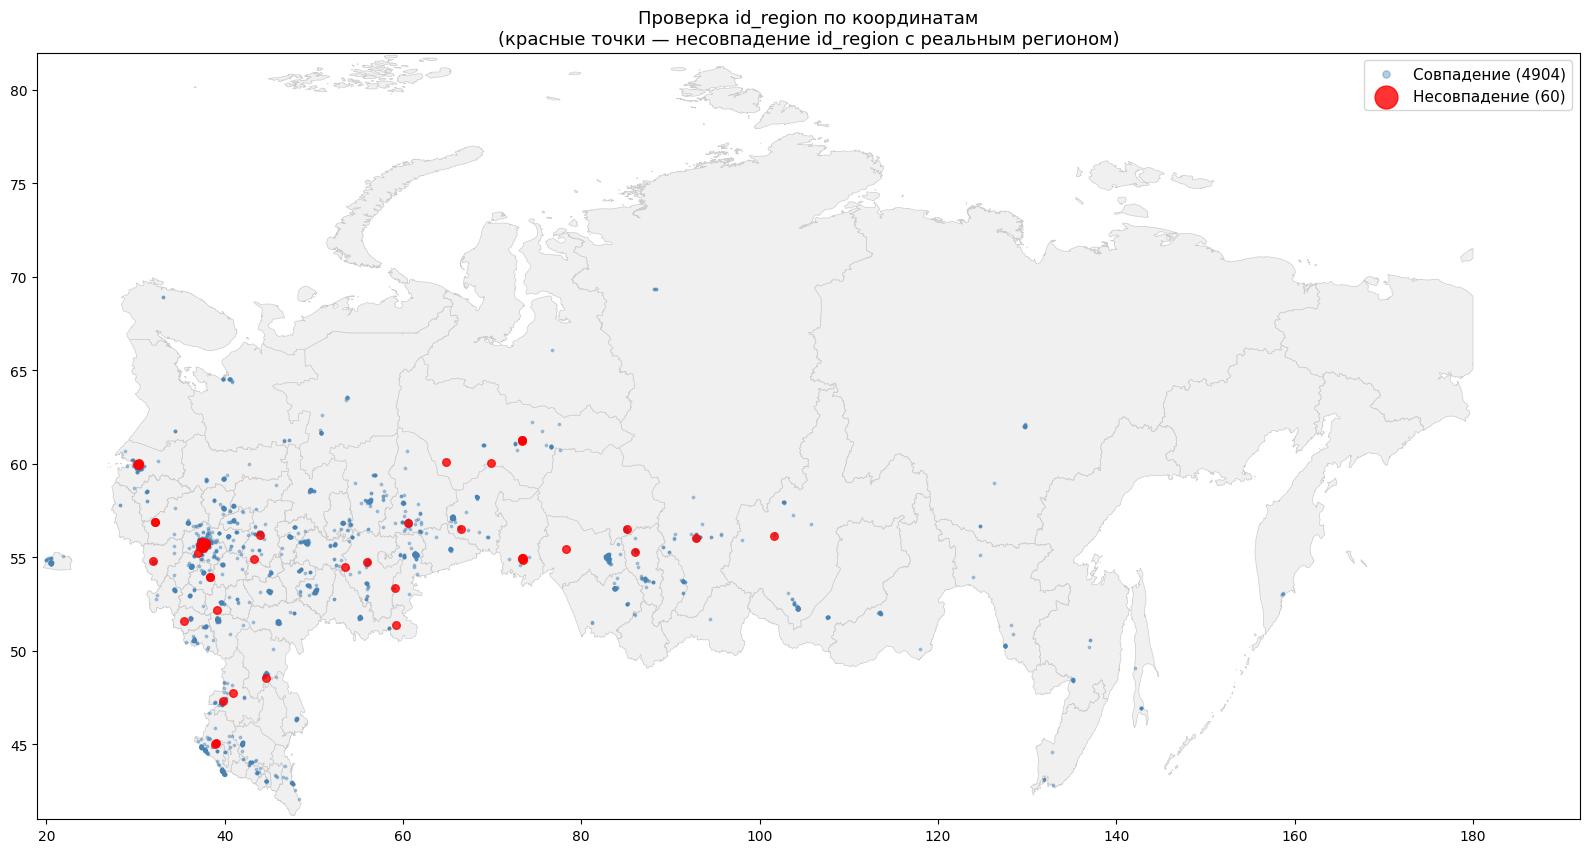

In [44]:
fig, ax = plt.subplots(figsize=(16, 10))

# Карта регионов
regions.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)

# Совпадения — синие
ok = matched[matched['match']]
ax.scatter(ok['geo_lon'], ok['geo_lat'], s=3, color='steelblue', alpha=0.4, label=f'Совпадение ({len(ok)})')

# Несовпадения — красные, крупнее
ax.scatter(mismatches['geo_lon'], mismatches['geo_lat'], s=30, color='red', alpha=0.8,
           zorder=5, label=f'Несовпадение ({len(mismatches)})')

ax.set_xlim(19, 192)
ax.set_ylim(41, 82)
ax.set_title('Проверка id_region по координатам\n(красные точки — несовпадение id_region с реальным регионом)', fontsize=13)
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.show()

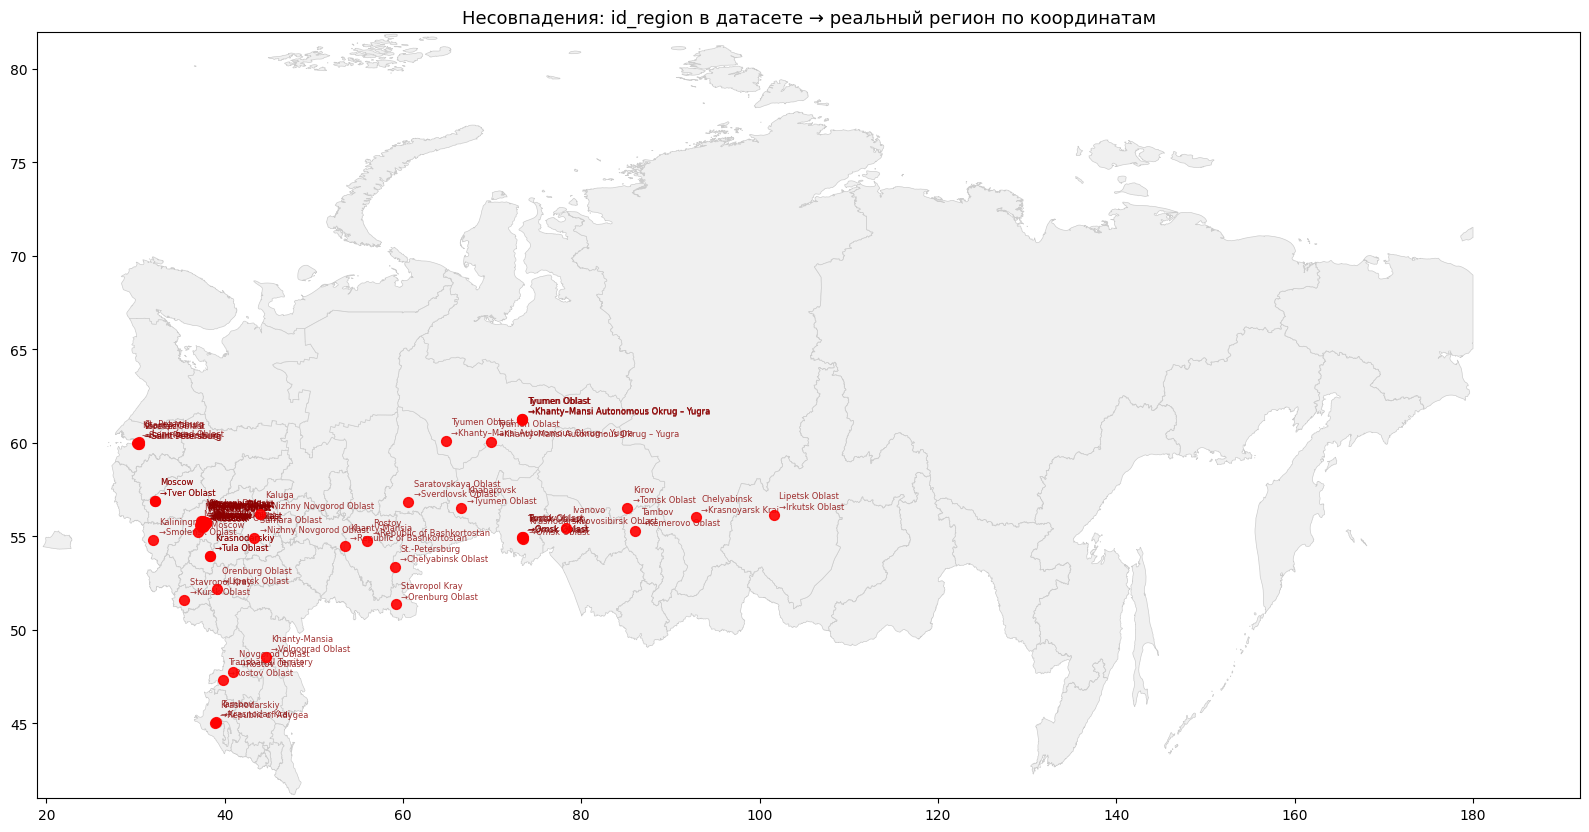

In [45]:
# Увеличенная карта только несовпадений с подписями
fig, ax = plt.subplots(figsize=(16, 10))
regions.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)

ax.scatter(mismatches['geo_lon'], mismatches['geo_lat'], s=50, color='red', alpha=0.9, zorder=5)

for _, row in mismatches.iterrows():
    ax.annotate(
        f"{row['id_region_name']}\n→{row['name_latin']}",
        xy=(row['geo_lon'], row['geo_lat']),
        fontsize=6, color='darkred', alpha=0.8,
        xytext=(4, 4), textcoords='offset points'
    )

ax.set_xlim(19, 192)
ax.set_ylim(41, 82)
ax.set_title('Несовпадения: id_region в датасете → реальный регион по координатам', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Выводы

- **98.8% совпадений** — `id_region` в датасете корректный
- Несовпадения (1.2%) — предположительно граничные точки между регионами
- Смотрим на карту: если красные точки кластеризуются на границах регионов — данные верные, это погрешность GeoJSON
- Код `200` (3577 записей) — мусорные данные, убрать при предобработке

## 7. Исправление id_region по координатам (полный датасет)

In [46]:
import time

# Spatial join на полном датасете (~10-20 минут)
print('Запуск spatial join на полном датасете...')
print(f'Записей: {len(df):,}')

mask_valid = (df['geo_lat'].between(41, 82)) & (df['geo_lon'].between(19, 192))
df_valid = df[mask_valid].copy().reset_index(drop=True)
df_invalid = df[~mask_valid].copy().reset_index(drop=True)

print(f'Валидных координат: {len(df_valid):,}')
print(f'Невалидных координат: {len(df_invalid):,}')

t0 = time.time()
geometry_full = [Point(lon, lat) for lon, lat in zip(df_valid['geo_lon'], df_valid['geo_lat'])]
gdf_full = gpd.GeoDataFrame(df_valid, geometry=geometry_full, crs='EPSG:4326')

joined_full = gpd.sjoin(gdf_full, regions[['official_code', 'name_latin', 'geometry']], how='left', predicate='within')
joined_full = joined_full[~joined_full.index.duplicated(keep='first')]

print(f'Spatial join выполнен за {time.time()-t0:.0f} сек.')

Запуск spatial join на полном датасете...
Записей: 11,358,150
Валидных координат: 11,358,149
Невалидных координат: 1
Spatial join выполнен за 280 сек.


In [47]:
df_valid['id_region_fixed'] = joined_full['official_code'].combine_first(
    joined_full['id_region'].astype(float)
).astype(int)

fixed_count = (df_valid['id_region'] != df_valid['id_region_fixed']).sum()
print(f'Исправлено записей: {fixed_count:,} ({fixed_count/len(df_valid)*100:.2f}%)')
print(f'Осталось без изменений: {len(df_valid) - fixed_count:,}')

df_valid['id_region'] = df_valid['id_region_fixed']
df_valid = df_valid.drop(columns=['id_region_fixed'])

df_corrected = pd.concat([df_valid, df_invalid], ignore_index=True)
print(f'\nИтоговый датасет: {len(df_corrected):,} записей')
df_corrected[['id_region', 'geo_lat', 'geo_lon']].head()

Исправлено записей: 166,272 (1.46%)
Осталось без изменений: 11,191,877

Итоговый датасет: 11,358,150 записей


,id_region,geo_lat,geo_lon
0,66,56.780112,60.699355
1,1,44.608154,40.138381
2,50,55.540060,37.725112
3,1,44.608154,40.138381
4,23,44.738685,37.713668


In [48]:
output_path = '../data/processed/input_data_region_fixed.csv'
df_corrected.to_csv(output_path, index=False)
print(f'Сохранено: {output_path}')
print(f'Итог: {len(df_corrected):,} строк, {df_corrected.shape[1]} колонок')

Сохранено: ../data/processed/input_data_region_fixed.csv
Итог: 11,358,150 строк, 15 колонок
